In [ ]:
# import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from my_nn import activations, loss, metrics, nn 


##### First we generate sample data for each task. We use the same input features for all tasks to keep things simple.
##### Then for binary classification we create a parabolic decision boundary.
##### For multiclass classification we use a hyperbolic decision boundary to create three classes.
##### For regression we use a parabolic surface.

In [35]:
# create data sets to use
# for all 3 pick 10000 random points in the square [-5,5]x[-5,5]
X = np.random.uniform(-5, 5, size=(10000, 2))
# for binary classification, label points above the curve y = x^2 - 2 as 1, below as 0
y_binary = (X[:,1] - X[:,0] ** 2 >= -2).astype(int) 
# for multi-class classification we will use the hyperbola y^2 - x^2 = 3 to create 3 classes
mask1 = (X[:,1] ** 2 - X[:,0] ** 2 >= 3) & (X[:,1] > 0)
mask2 = (X[:,1] ** 2 - X[:,0] ** 2 >= 3)  & (X[:,1] < 0)
y_multiclass = mask1  + 2 * mask2
# for regression we will use the function y = x^2 + y^2
y_regression = np.sum(X**2, axis=1)

##### Next we visualize the data for each task

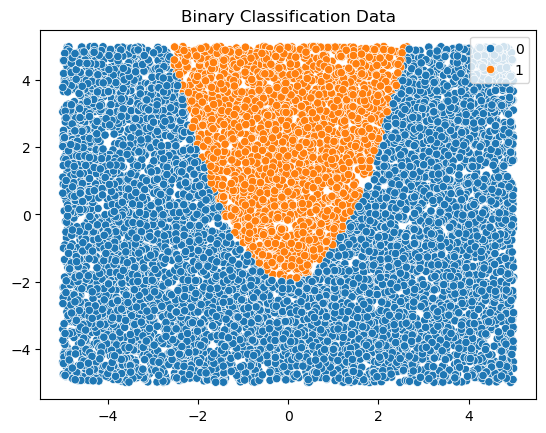

In [36]:
# Binary classification data plot
sns.scatterplot(x=X[:,0], y=X[:,1], hue=y_binary)
plt.title("Binary Classification Data")
plt.show()

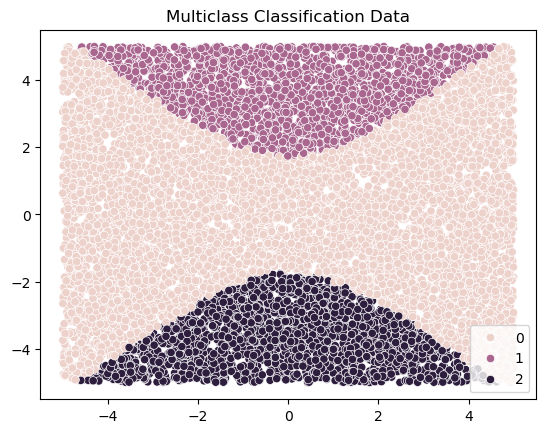

In [37]:
# multiclass classification data plot
sns.scatterplot(x=X[:,0], y=X[:,1], hue=y_multiclass)
plt.title("Multiclass Classification Data")
plt.show()

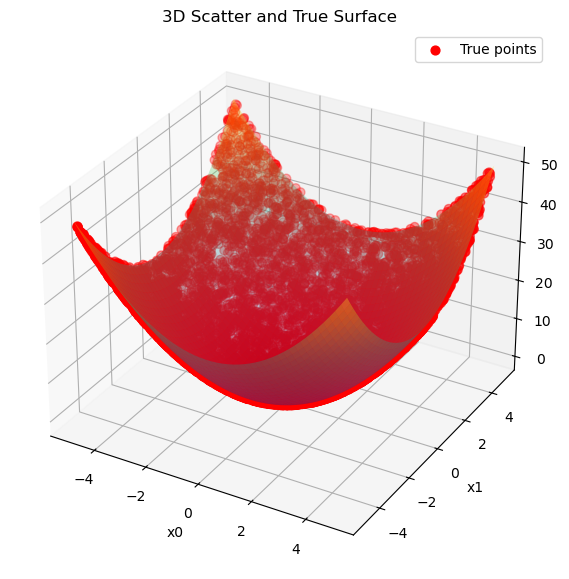

In [38]:
# Regression data plot
# Create grid for surface

x0_grid = np.linspace(-5, 5, 50)
x1_grid = np.linspace(-5, 5, 50)
x0_mesh, x1_mesh = np.meshgrid(x0_grid, x1_grid)
y_mesh = x0_mesh**2 + x1_mesh**2  # true surface
# for the scatterplot we'll choose a random sample of 1000 points 
#indices = np.random.choice(X.shape[0], size=1000, replace=False)
#X_sample = X[indices]
#y_sample = y_regression[indices]
# Plot
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Surface for true function
ax.plot_surface(x0_mesh, x1_mesh, y_mesh, alpha=0.3, cmap='viridis')

# Scatter true points
ax.scatter(X[:, 0], X[:, 1], y_regression, color='red', label='True points', s=40)



ax.set_xlabel('x0')
ax.set_ylabel('x1')
ax.set_zlabel('y')
ax.set_title('3D Scatter and True Surface')
ax.legend()

plt.show()

##### Next we set up the models. We will use the same basic architecture for all tasks, but change the output layer and loss function as appropriate for each task.


In [39]:
# reshape y arrays as needed
y_binary = y_binary.reshape(len(y_binary), 1)
y_regression = y_regression.reshape(len(y_regression), 1)
y_multiclass = y_multiclass.reshape(len(y_multiclass), 1)

In [40]:
model_binary = nn.FeedForward(
    nn.Dense(2, 30, activation="relu"),
    nn.Dense(30, 30, activation="relu"),
    nn.Dense(30, 30, activation="relu"),
    nn.Dense(30, 1, activation="sigmoid")
)

model_multiclass = nn.FeedForward(
    nn.Dense(2, 30, activation="relu"),
    nn.Dense(30, 30, activation="relu"),
    nn.Dense(30, 30, activation="relu"),
    nn.Dense(30, 3, activation="identity")
)

model_regression = nn.FeedForward(
    nn.Dense(2, 30, activation="relu"),
    nn.Dense(30, 30, activation="relu"),
    nn.Dense(30, 30, activation="relu"),
    nn.Dense(30, 1, activation="identity")
)

In [42]:
# we create a training and test split for each data set.
X_binary_train,X_binary_test,y_binary_train,y_binary_test = nn.train_test_split(X,y_binary, train_size=0.8)
X_multiclass_train,X_multiclass_test,y_multiclass_train,y_multiclass_test = nn.train_test_split(X,y_multiclass, train_size=0.8)
X_regression_train,X_regression_test,y_regression_train,y_regression_test = nn.train_test_split(X,y_regression, train_size=0.8)

##### Next , train all 3 models for 200 epochs each, using a batch size of 32 and a learning rate of 0.01.

In [43]:
history_binary = model_binary.fit(X_binary_train, y_binary_train, epochs=200 ,learning_rate=0.01, batch_size=32, verbose=False, loss_fn="binary_cross_entropy", metric=metrics.accuracy, val_set=(X_binary_test,y_binary_test))

Epoch 1 complete. Average Loss: 0.4998 , accuracy 0.8186 -  Validation Loss: 0.3485, Validation accuracy 0.8190
Epoch 2 complete. Average Loss: 0.3165 , accuracy 0.8458 -  Validation Loss: 0.3055, Validation accuracy 0.8440
Epoch 3 complete. Average Loss: 0.2835 , accuracy 0.8576 -  Validation Loss: 0.2788, Validation accuracy 0.8525
Epoch 4 complete. Average Loss: 0.2620 , accuracy 0.8708 -  Validation Loss: 0.2605, Validation accuracy 0.8680
Epoch 5 complete. Average Loss: 0.2468 , accuracy 0.8831 -  Validation Loss: 0.2471, Validation accuracy 0.8820
Epoch 6 complete. Average Loss: 0.2356 , accuracy 0.8914 -  Validation Loss: 0.2371, Validation accuracy 0.8905
Epoch 7 complete. Average Loss: 0.2272 , accuracy 0.8971 -  Validation Loss: 0.2295, Validation accuracy 0.8925
Epoch 8 complete. Average Loss: 0.2206 , accuracy 0.9001 -  Validation Loss: 0.2234, Validation accuracy 0.8970
Epoch 9 complete. Average Loss: 0.2153 , accuracy 0.9014 -  Validation Loss: 0.2185, Validation accuracy

In [44]:
history_multiclass = model_multiclass.fit(X_multiclass_train, y_multiclass_train, epochs=200 ,learning_rate=0.01, batch_size=32, verbose=False, loss_fn="categorical_cross_entropy", metric=metrics.accuracy, val_set=(X_multiclass_test,y_multiclass_test))

Epoch 1 complete. Average Loss: 0.8208 , accuracy 0.7041 -  Validation Loss: 0.7294, Validation accuracy 0.7080
Epoch 2 complete. Average Loss: 0.6739 , accuracy 0.7292 -  Validation Loss: 0.6336, Validation accuracy 0.7340
Epoch 3 complete. Average Loss: 0.5965 , accuracy 0.7522 -  Validation Loss: 0.5687, Validation accuracy 0.7530
Epoch 4 complete. Average Loss: 0.5401 , accuracy 0.8084 -  Validation Loss: 0.5200, Validation accuracy 0.8035
Epoch 5 complete. Average Loss: 0.4957 , accuracy 0.8395 -  Validation Loss: 0.4804, Validation accuracy 0.8450
Epoch 6 complete. Average Loss: 0.4597 , accuracy 0.8631 -  Validation Loss: 0.4453, Validation accuracy 0.8645
Epoch 7 complete. Average Loss: 0.4289 , accuracy 0.8692 -  Validation Loss: 0.4173, Validation accuracy 0.8690
Epoch 8 complete. Average Loss: 0.4023 , accuracy 0.8841 -  Validation Loss: 0.3916, Validation accuracy 0.8810
Epoch 9 complete. Average Loss: 0.3791 , accuracy 0.8866 -  Validation Loss: 0.3698, Validation accuracy

In [45]:
history_regression = model_regression.fit(X_regression_train, y_regression_train, epochs=200 ,learning_rate=0.01, batch_size=32, verbose=False, loss_fn="mse", metric=metrics.mse, val_set=(X_regression_test,y_regression_test))

Epoch 1 complete. Average Loss: 27.5427 , mse 16.5944 -  Validation Loss: 16.2356, Validation mse 16.2356
Epoch 2 complete. Average Loss: 14.7310 , mse 12.8658 -  Validation Loss: 12.7062, Validation mse 12.7062
Epoch 3 complete. Average Loss: 11.4541 , mse 10.3091 -  Validation Loss: 10.2488, Validation mse 10.2488
Epoch 4 complete. Average Loss: 8.7906 , mse 7.4192 -  Validation Loss: 7.4140, Validation mse 7.4140
Epoch 5 complete. Average Loss: 6.4742 , mse 5.3242 -  Validation Loss: 5.3788, Validation mse 5.3788
Epoch 6 complete. Average Loss: 4.6074 , mse 3.9085 -  Validation Loss: 3.9684, Validation mse 3.9684
Epoch 7 complete. Average Loss: 3.3273 , mse 2.7651 -  Validation Loss: 2.8084, Validation mse 2.8084
Epoch 8 complete. Average Loss: 2.4900 , mse 2.2307 -  Validation Loss: 2.2087, Validation mse 2.2087
Epoch 9 complete. Average Loss: 1.9287 , mse 1.6368 -  Validation Loss: 1.6023, Validation mse 1.6023
Epoch 10 complete. Average Loss: 1.5557 , mse 1.3135 -  Validation Los

##### Look a the training history for each model. We will plot the training and validation loss and accuracy (where applicable) over epochs.

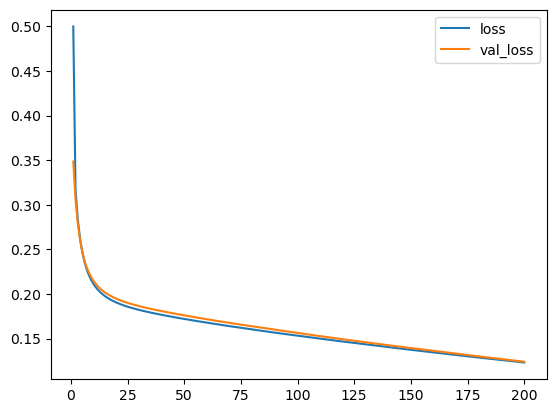

In [46]:
# Plot training & validation loss values for binary classification
nn.plot_history(history_binary, "loss", "val_loss")

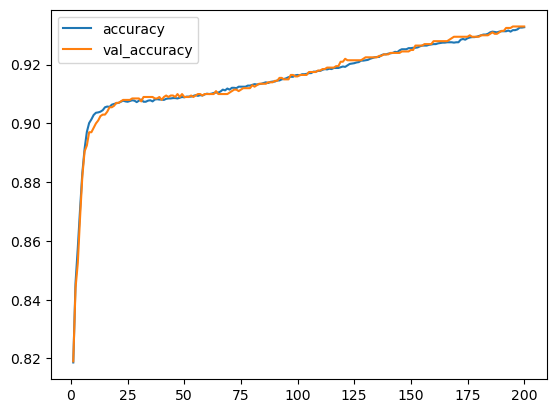

In [47]:
# plot training and validation accuracy for binary classification
nn.plot_history(history_binary, "accuracy", "val_accuracy")

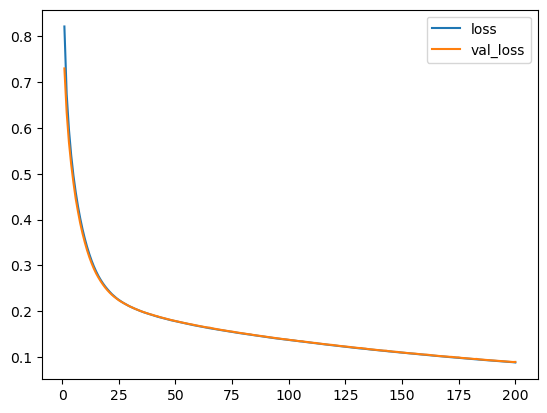

In [48]:
# plot training & validation loss values for multiclass classification
nn.plot_history(history_multiclass, "loss", "val_loss")

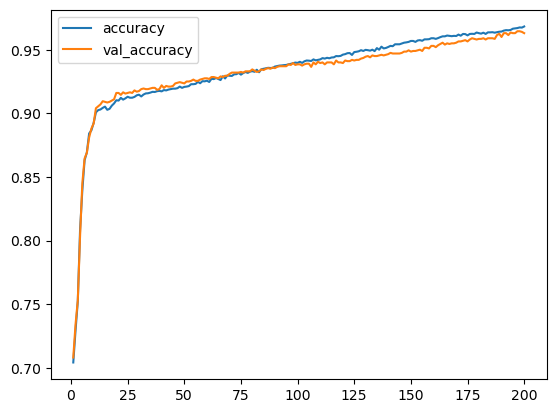

In [49]:
# plot training & validation accuracy for multiclass classification
nn.plot_history(history_multiclass, "accuracy", "val_accuracy")

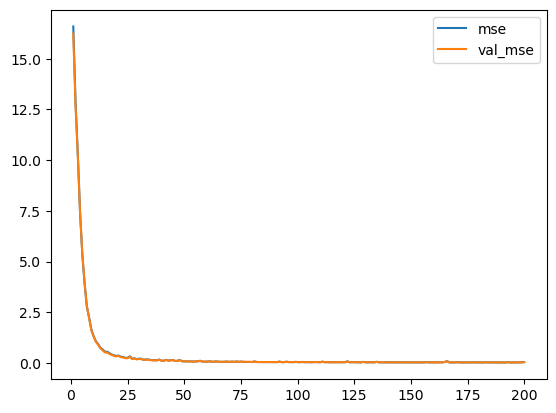

In [50]:
# plot mse loss for regression
nn.plot_history(history_regression, "mse", "val_mse")

##### Finally we visualize the true decision boundaries for the classification tasks and the true surface for the regression task, along with the model predictions.

First we look at basic metrics on the performance on the whole set. Accuracy for classification, MSE for the regression

In [51]:
y_binary_pred = model_binary.predict(X)
y_multiclass_pred = model_multiclass.predict(X)
y_regression_pred = model_regression.predict(X)

In [52]:
# convert the classification predictions to class labels
y_binary_pred_labels = (y_binary_pred >= 0.5).astype(int)
y_multiclass_pred_labels = np.argmax(y_multiclass_pred, axis=1)

In [53]:
binary_acc = metrics.accuracy(y_binary, y_binary_pred_labels)
multiclass_acc = metrics.accuracy(y_multiclass, y_multiclass_pred_labels)
regression_mse = metrics.mse(y_regression, y_regression_pred)

In [54]:
print(f"Binary classification accuracy: {binary_acc:.4f}")
print(f"Multiclass classification accuracy: {multiclass_acc:.4f}")
print(f"Regression MSE: {regression_mse:.4f}")  

Binary classification accuracy: 0.9328
Multiclass classification accuracy: 0.9672
Regression MSE: 0.0386


C:\Users\ronsp\AppData\Local\Temp\ipykernel_69236\4168071158.py:10: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contour(X_vals, Y_vals, F, [3], colors='k', linestyles='solid', label = 'y^2 - x^2 = 3')


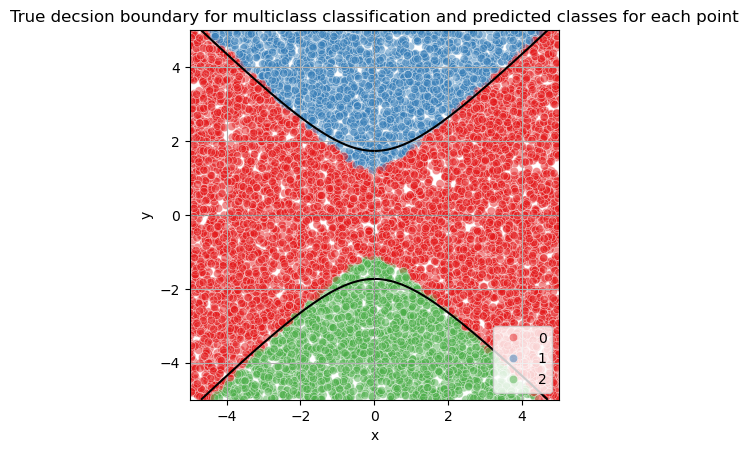

In [ ]:



# Create a grid of x and y values
x = np.linspace(-5, 5, 400)
y = np.linspace(-5, 5, 400)
X_vals, Y_vals = np.meshgrid(x, y)

# Define the hyperbola equation
F = Y_vals**2- X_vals**2 

# Plot the hyperbola using contour
plt.contour(X_vals, Y_vals, F, [3], colors='k', linestyles='solid')
sns.scatterplot(x=X[:,0], y=X[:,1], hue=y_multiclass_pred_labels.ravel(), palette='Set1', alpha=0.5)

# Add labels and title
plt.xlabel('x')
plt.ylabel('y')
plt.title("True decision boundary for multiclass classification and predicted classes for each point")
plt.grid(True)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.5)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.5)
plt.gca().set_aspect('equal', adjustable='box') # Ensure proper aspect ratio
plt.show()

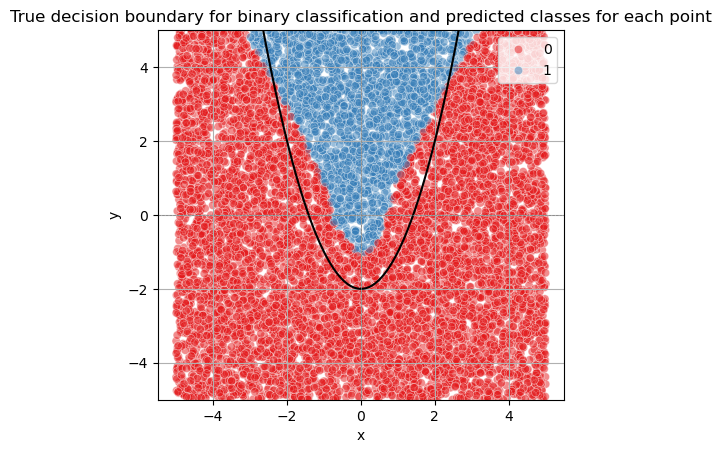

In [61]:
x = np.linspace(-5, 5, 400)
y = x**2 - 2
plt.plot(x, y, color='k', linestyle='solid')
sns.scatterplot(x=X[:,0], y=X[:,1], hue=y_binary_pred_labels.ravel(), palette='Set1', alpha=0.5)

# Add labels and title
plt.xlabel('x')
plt.ylabel('y')
plt.title("True decision boundary for binary classification and predicted classes for each point")
plt.grid(True)
plt.ylim(-5,5)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.5)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.5)
plt.gca().set_aspect('equal', adjustable='box') # Ensure proper aspect ratio
plt.show()

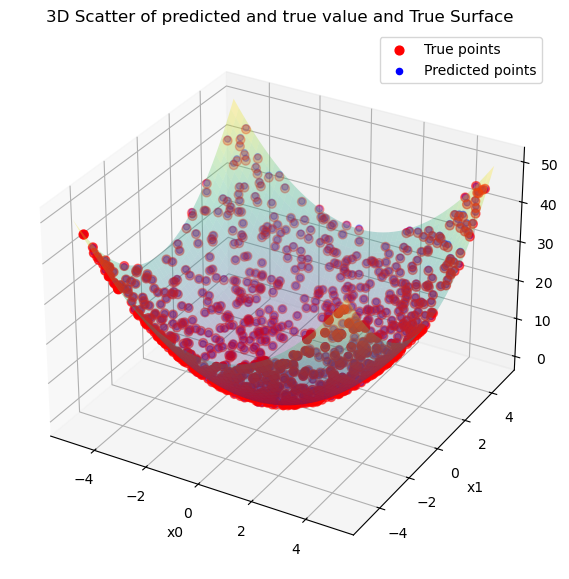

In [66]:
# Regression data plot
# Create grid for surface
idx = np.random.choice(len(X), size=1000, replace=False)
X_sample = X[idx]
y_sample = y_regression[idx]
y_pred_sample = y_regression_pred[idx]
x0_grid = np.linspace(-5, 5, 50)
x1_grid = np.linspace(-5, 5, 50)
x0_mesh, x1_mesh = np.meshgrid(x0_grid, x1_grid)
y_mesh = x0_mesh**2 + x1_mesh**2  # true surface
# for the scatterplot we'll choose a random sample of 1000 points 
#indices = np.random.choice(X.shape[0], size=1000, replace=False)
#X_sample = X[indices]
#y_sample = y_regression[indices]
# Plot
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Surface for true function
ax.plot_surface(x0_mesh, x1_mesh, y_mesh, alpha=0.3, cmap='viridis')

# Scatter true points
ax.scatter(X_sample[:, 0], X_sample[:, 1], y_sample.ravel(), color='red', label='True points', s=40)
# Scatter predicted points
ax.scatter(X_sample[:, 0], X_sample[:, 1], y_pred_sample.ravel(), color='blue', label='Predicted points', s=20)



ax.set_xlabel('x0')
ax.set_ylabel('x1')
ax.set_zlabel('y')
ax.set_title('3D Scatter of predicted and true value and True Surface')
ax.legend()

plt.show()

##### Finally a little exploration of residuals and confusion matrices for the regression and multiclass classification tasks.


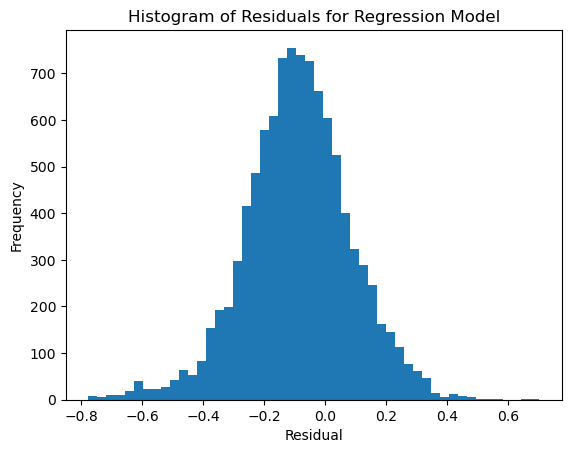

In [76]:
residuals = (y_regression - y_regression_pred).flatten()
plt.hist(residuals, bins=50)
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Histogram of Residuals for Regression Model")
plt.show()


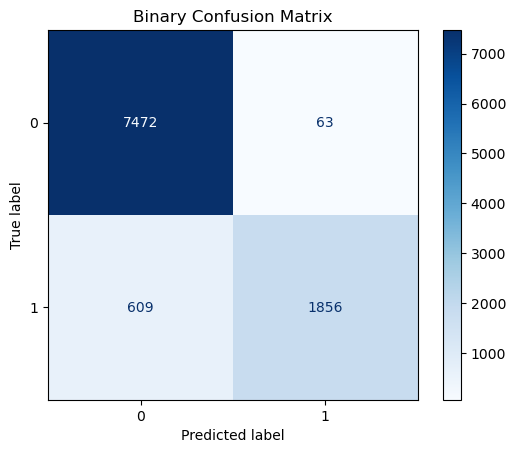

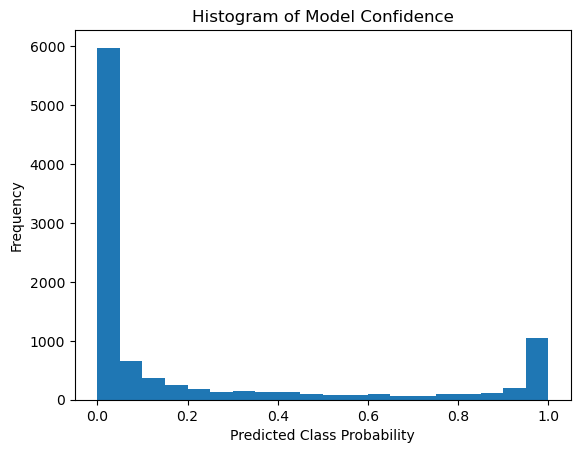

In [79]:

cm = confusion_matrix(y_binary, y_binary_pred_labels)
disp = ConfusionMatrixDisplay(cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Binary Confusion Matrix")
plt.show()

# Step 4: histogram of max probabilities (confidence)
max_probs = np.max(y_binary_pred, axis=1)
plt.hist(max_probs, bins=20)
plt.xlabel("Predicted Class Probability")
plt.ylabel("Frequency")
plt.title("Histogram of Model Confidence")
plt.show()

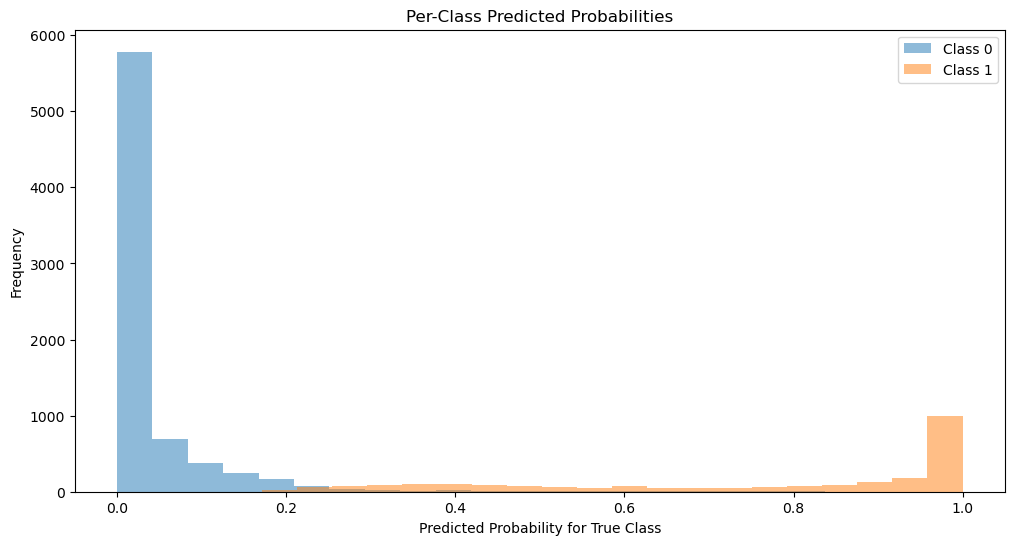

In [80]:
# y_prob: softmax probabilities from your model (n_samples, n_classes)
# y_true: true class labels (integers 0..n_classes-1)
n_classes = 2

plt.figure(figsize=(12, 6))

for cls in range(n_classes):
    # select probabilities for samples whose true label is cls
    cls_probs = y_binary_pred[y_binary.ravel() == cls]
    
    plt.hist(cls_probs, bins=20, alpha=0.5, label=f"Class {cls}")

plt.xlabel("Predicted Probability for True Class")
plt.ylabel("Frequency")
plt.title("Per-Class Predicted Probabilities")
plt.legend()
plt.show()

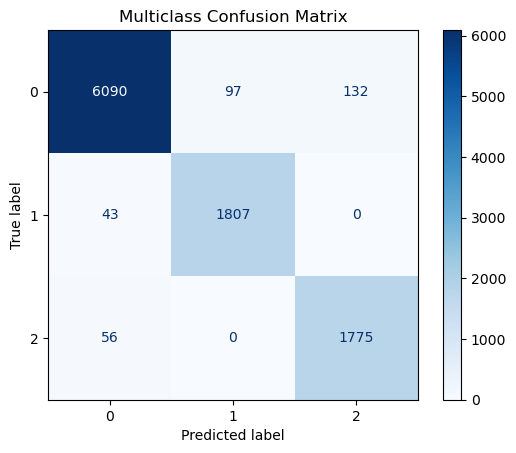

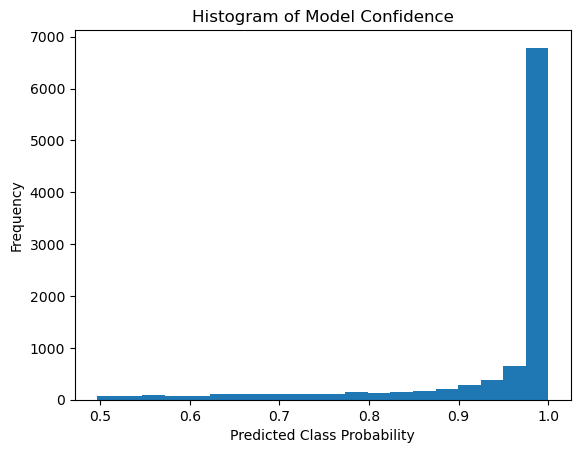

In [77]:



# y_multiclass_pred: raw logits from your model
# y_multiclass_true: true class labels (integers 0,1,2,...)

# Step 1: softmax the logits
def softmax(z):
    e_z = np.exp(z - np.max(z, axis=1, keepdims=True))
    return e_z / np.sum(e_z, axis=1, keepdims=True)

y_prob = softmax(y_multiclass_pred)

# Step 2: predicted classes
y_pred_labels = np.argmax(y_prob, axis=1)

# Step 3: confusion matrix
cm = confusion_matrix(y_multiclass, y_pred_labels)
disp = ConfusionMatrixDisplay(cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Multiclass Confusion Matrix")
plt.show()

# Step 4: histogram of max probabilities (confidence)
max_probs = np.max(y_prob, axis=1)
plt.hist(max_probs, bins=20)
plt.xlabel("Predicted Class Probability")
plt.ylabel("Frequency")
plt.title("Histogram of Model Confidence")
plt.show()


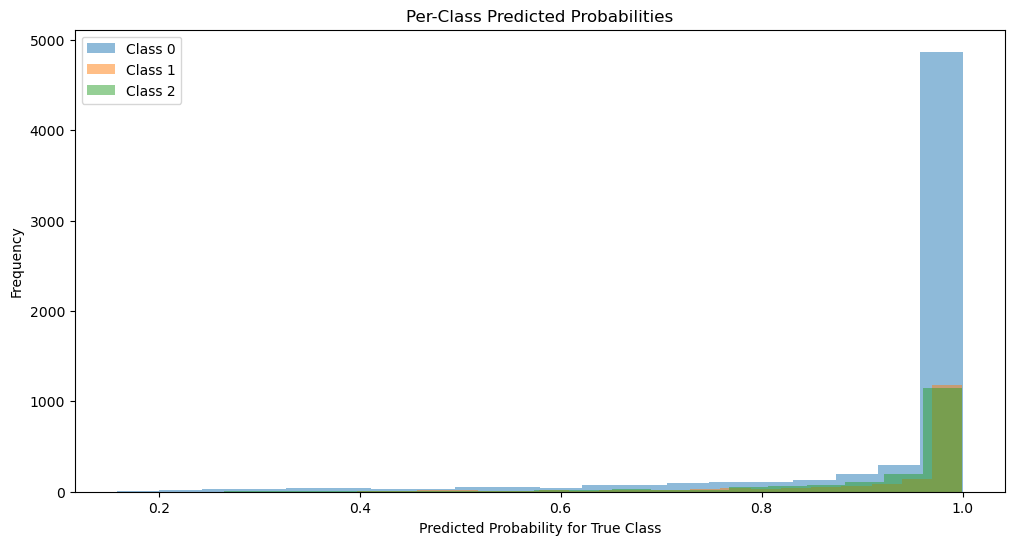

In [78]:


# y_prob: softmax probabilities from your model (n_samples, n_classes)
# y_true: true class labels (integers 0..n_classes-1)
n_classes = y_prob.shape[1]

plt.figure(figsize=(12, 6))

for cls in range(n_classes):
    # select probabilities for samples whose true label is cls
    cls_probs = y_prob[y_multiclass.ravel() == cls, cls]
    
    plt.hist(cls_probs, bins=20, alpha=0.5, label=f"Class {cls}")

plt.xlabel("Predicted Probability for True Class")
plt.ylabel("Frequency")
plt.title("Per-Class Predicted Probabilities")
plt.legend()
plt.show()
